<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab05_Pythor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 1 - Prediccion de Productividad con Red Neuronal (PyTorch)**
**Nombre:** Yulitza Alcibia Miranda

**Grupo:** 2

**Dataset:** Student Productivity & Digital Distraction Dataset

**Link:** https://drive.google.com/file/d/1PHOn_1-26Kj2jzM3TumXUhsu4ZLpxeZV/view?usp=sharing

## Descripcion del Dataset
El dataset contiene informacion de **20,000 estudiantes** con variables de habitos academicos,
uso digital y rendimiento.

## Variable objetivo
Se predice **`productivity_score`** (0-100), que representa el nivel general de productividad.

## Estructura del laboratorio
1. Carga y exploracion de datos
2. Normalizacion de variables
3. Preparacion de tensores y `DataLoader`
4. Definicion y entrenamiento de una red neuronal
5. Evaluacion y prediccion en un nuevo estudiante



In [3]:
# Librería para manejo de directorios y rutas
import os

# Librería para computación vectorial y científica
import numpy as np

# Librería para graficar
from matplotlib import pyplot

# Permite mostrar las gráficas dentro del cuadernillo
%matplotlib inline
import torch

# Paso 1 — Cargar el dataset
Se carga el archivo `student_productivity_distraction_dataset_20000.csv` desde
**Google Drive** utilizando `numpy.loadtxt`. Se omiten las columnas `student_id`
y `gender` por ser un identificador y una variable de texto respectivamente,
trabajando con **15 variables numéricas** como predictoras y `productivity_score`
como variable objetivo, obteniendo un total de **20,000 ejemplos** de entrenamiento.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = np.loadtxt('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/student_productivity_distraction_dataset_20000.csv',
                   delimiter=',',
                   skiprows=1,
                   usecols=(1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17))

# Separamos X (variables predictoras) e y (variable a predecir)
X = data[:, :15]
y = data[:, 15]

m = y.size

print('Numero de ejemplos (m):', m)
print('Numero de variables (X):', X.shape[1])


print('{:>8s}{:>10s}{:>12s}{:>14s}{:>14s}{:>10s}{:>10s}{:>8s}{:>8s}{:>10s}{:>12s}{:>13s}{:>8s}{:>13s}{:>12s}{:>10s}'.format(
'X[:,0]',
'X[:,1]',
'X[:,2]',
'X[:,3]',
'X[:,4]',
'X[:,5]',
'X[:,6]',
'X[:,7]',
'X[:,8]',
'X[:,9]',
'X[:,10]',
'X[:,11]',
'X[:,12]',
'X[:,13]',
'X[:,14]',
'y'
))
print('-' * 170)
for i in range(10):
    print('{:8.0f}{:10.0f}{:12.0f}{:14.0f}{:14.0f}{:10.0f}{:10.0f}{:8.0f}{:8.0f}{:10.0f}{:12.0f}{:13.0f}{:8.0f}{:13.0f}{:12.0f}{:10.0f}'.format(
        X[i, 0],   # age
        X[i, 1],   # study_hours_per_day
        X[i, 2],   # sleep_hours
        X[i, 3],   # phone_usage_hours
        X[i, 4],   # social_media_hours
        X[i, 5],   # youtube_hours
        X[i, 6],   # gaming_hours
        X[i, 7],   # breaks_per_day
        X[i, 8],   # coffee_intake_mg
        X[i, 9],   # exercise_minutes
        X[i, 10],  # assignments_completed
        X[i, 11],  # attendance_percentage
        X[i, 12],  # stress_level
        X[i, 13],  # focus_score
        X[i, 14],  # final_grade
        y[i]))

Numero de ejemplos (m): 20000
Numero de variables (X): 15
  X[:,0]    X[:,1]      X[:,2]        X[:,3]        X[:,4]    X[:,5]    X[:,6]  X[:,7]  X[:,8]    X[:,9]     X[:,10]      X[:,11] X[:,12]      X[:,13]     X[:,14]         y
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      23         4           4             3             3         2         5       6     347       111           2           57      10           57          82        34
      20         6           7             5             2         3         2      13     403        28          10           91      10           49          61        49
      29         5           3             5             4         0         5       1     419       102           8           63       2           38          86        37
      27         3           5            10             4         6         3 

---

## Paso 2: División y Normalización

**Orden correcto:** Primero se divide el dataset en conjuntos de entrenamiento (80 %) y
prueba (20 %), y **luego** se normaliza. Los parámetros `mu` y `sigma` se calculan
**únicamente con los datos de entrenamiento** y después se aplican al conjunto de prueba.
Esto evita el *data leakage* (filtrado de información del test hacia el train).


In [4]:
def featureNormalize(X):

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [5]:
# PASO 1: Dividir en train/test ANTES de normalizar
total      = len(X)
train_size = int(total * 0.8)   # 16,000 ejemplos

X_train_raw = X[:train_size]
X_test_raw  = X[train_size:]
y_train_raw = y[:train_size]
y_test_raw  = y[train_size:]

print(f"Ejemplos de entrenamiento: {X_train_raw.shape[0]}")
print(f"Ejemplos de prueba:        {X_test_raw.shape[0]}")


Ejemplos de entrenamiento: 16000
Ejemplos de prueba:        4000


In [6]:

X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm             = (X_test_raw - mu) / sigma

print('Media calculada (train):          ', mu)
print('Desviacion estandar calculada (train):', sigma)
print('Primeras filas de X_train_norm:')
print(X_train_norm[:3])


Media calculada (train):           [ 23.0388125    5.25508875   6.52764313   6.2628925    4.00815437
   2.98852938   2.98468375   7.54625    248.92625     59.659125
   9.505       69.80539187   5.4708125   64.3499375   70.23851687]
Desviacion estandar calculada (train): [  3.76381536   2.74354069   2.02526052   3.31093602   2.30372989
   1.73475552   1.73143852   4.02265285 143.56432813  34.73655214
   5.79666715  17.34563004   2.87063113  20.16397422  17.28841133]
Primeras filas de X_train_norm:
[[-0.01031201 -0.32989806 -1.43075081 -0.87071828 -0.55481955 -0.66783438
   1.314119   -0.38438564  0.68313453  1.47800722 -1.2947095  -0.72614208
   1.57776715 -0.36450838  0.67279074]
 [-0.80737555  0.32254351  0.02585192 -0.23645655 -1.08439552  0.08155076
  -0.72464817  1.35575955  1.07320357 -0.91140666  0.0853939   1.23746489
   1.57776715 -0.76125556 -0.5401605 ]
 [ 1.58381507 -0.10026779 -1.61344335 -0.43277565 -0.16414875 -1.61897705
   0.99646406 -1.62734649  1.18465187  1.21891415 

## PASO 3: Convertir a tensores PyTorch

In [7]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_train_tensor = torch.from_numpy(X_train_norm).float().to(device)
y_train_tensor = torch.from_numpy(y_train_raw).float().to(device)

X_test_tensor  = torch.from_numpy(X_test_norm).float().to(device)
y_test_tensor  = torch.from_numpy(y_test_raw).float().to(device)

print(f'Train: {X_train_tensor.shape}   Test: {X_test_tensor.shape}')


Train: torch.Size([16000, 15])   Test: torch.Size([4000, 15])


### PASO 4: Crear Dataset personalizado

In [8]:


class StudentDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


train_dataset = StudentDataset(X_train_tensor, y_train_tensor)
test_dataset  = StudentDataset(X_test_tensor,  y_test_tensor)

print(f'Ejemplos de entrenamiento: {len(train_dataset)}')
print(f'Ejemplos de evaluacion:    {len(test_dataset)}')


Ejemplos de entrenamiento: 16000
Ejemplos de evaluacion:    4000


# PASO 5: Crear DataLoader

In [10]:

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=100, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=100, shuffle=False
)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de evaluacion:    {len(test_loader)}')


Batches de entrenamiento: 160
Batches de evaluacion:    40


## PASO 6: DEFINICION DE LA RED NEURAL SECUENCIAL

In [11]:

D_in  = 15
H     = 64
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

print(model)
print(f'\nParametros del modelo: {sum(p.numel() for p in model.parameters())}')


Sequential(
  (0): Linear(in_features=15, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)

Parametros del modelo: 1089


In [12]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


### PASO 7: Entrenamiento
En cada `epoch` el modelo recorre todos los batches de entrenamiento,
calcula predicciones, mide el error con MSE y ajusta los pesos mediante
descenso por gradiente estocastico (SGD).
El orden correcto dentro del loop es: **zero_grad → forward → loss → backward → step**.
La curva de `train_losses` debe descender si el modelo esta aprendiendo.


In [13]:

epochs    = 100
log_each  = 10
train_losses = []
test_losses_epoch = []   # loss en test al final de cada epoch

model.train()
for e in range(1, epochs + 1):

    # ── Fase de entrenamiento ──
    model.train()
    batch_losses = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()          # 1. limpiar gradientes
        y_pred = model(x_b).squeeze()  # 2. forward
        loss   = criterion(y_pred, y_b)# 3. calcular error
        batch_losses.append(loss.item())
        loss.backward()                # 4. backward
        optimizer.step()               # 5. actualizar pesos

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Fase de evaluacion en test (sin gradientes) ──
    model.eval()
    with torch.no_grad():
        t_losses = []
        for x_b, y_b in test_loader:
            y_pred = model(x_b).squeeze()
            t_losses.append(criterion(y_pred, y_b).item())
        test_loss_e = np.mean(t_losses)
        test_losses_epoch.append(test_loss_e)

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  Train Loss: {train_loss:.4f}  Test Loss: {test_loss_e:.4f}')


Epoch 10/100  Train Loss: 0.1519  Test Loss: 0.1193
Epoch 20/100  Train Loss: 0.9835  Test Loss: 6.3145
Epoch 30/100  Train Loss: 0.0345  Test Loss: 0.1293
Epoch 40/100  Train Loss: 0.2130  Test Loss: 0.1400
Epoch 50/100  Train Loss: 0.1739  Test Loss: 0.1682
Epoch 60/100  Train Loss: 0.0051  Test Loss: 0.0102
Epoch 70/100  Train Loss: 0.0269  Test Loss: 0.0663
Epoch 80/100  Train Loss: 0.0148  Test Loss: 0.0373
Epoch 90/100  Train Loss: 0.0149  Test Loss: 0.0266
Epoch 100/100  Train Loss: 0.0369  Test Loss: 0.0370


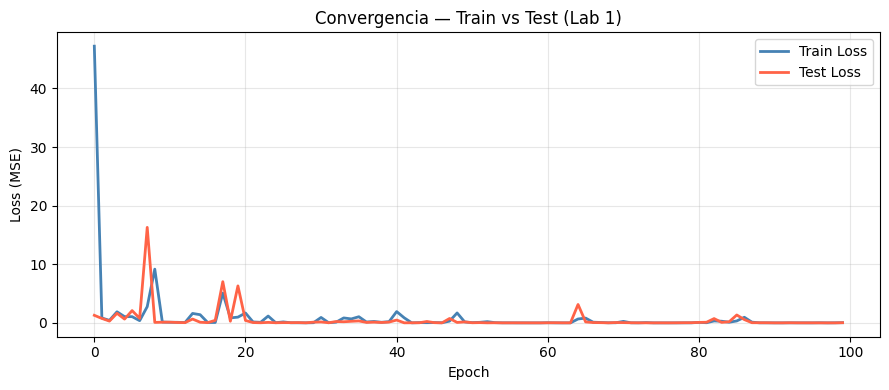

Train Loss final : 0.0369
Test  Loss final : 0.0370


In [14]:
# Grafica: Train Loss vs Test Loss por epoch
pyplot.figure(figsize=(9, 4))
pyplot.plot(train_losses,       color='steelblue', lw=2, label='Train Loss')
pyplot.plot(test_losses_epoch,  color='tomato',    lw=2, label='Test Loss')
pyplot.xlabel('Epoch')
pyplot.ylabel('Loss (MSE)')
pyplot.title('Convergencia — Train vs Test (Lab 1)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final : {train_losses[-1]:.4f}')
print(f'Test  Loss final : {test_losses_epoch[-1]:.4f}')


In [15]:

PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_estudiantes.pt'
torch.save(model.state_dict(), PATH)
print(f'Modelo guardado en: {PATH}')


Modelo guardado en: /content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_estudiantes.pt


In [16]:
# Cargar modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print('Modelo cargado correctamente ✅')


Modelo cargado correctamente ✅


# PASO 8: Predicciones individuales sobre datos reales del conjunto de PRUEBA
Se toman 5 estudiantes del test y se compara prediccion vs valor real

In [18]:

num_muestras = 5

print('\n═══════════════════════════════════════════════════════')
print('       PREDICCION vs REAL — DATOS DE TEST              ')
print('═══════════════════════════════════════════════════════')
print(f"{'Estudiante':<12} {'Prediccion':>12} {'Real':>8} {'Error abs':>10}")
print('-' * 48)

model.eval()
with torch.no_grad():
    for i in range(num_muestras):
        x_sample = X_test_tensor[i].unsqueeze(0)   # shape (1, 15)
        y_real   = y_test_tensor[i].item()
        pred     = model(x_sample).squeeze().item()
        error    = abs(pred - y_real)
        print(f'{i+1:<12} {pred:>12.2f} {y_real:>8.0f} {error:>10.2f}')

print('═══════════════════════════════════════════════════════')



═══════════════════════════════════════════════════════
       PREDICCION vs REAL — DATOS DE TEST              
═══════════════════════════════════════════════════════
Estudiante     Prediccion     Real  Error abs
------------------------------------------------
1                   64.77       65       0.23
2                   28.09       28       0.06
3                   50.11       50       0.17
4                   39.15       39       0.19
5                   53.49       53       0.09
═══════════════════════════════════════════════════════


# Laboratorio 3: Clasificacion Binaria de Supervivencia (PyTorch)
**NOMBRE:** Yulitza Alcibia Miranda  
**GRUPO:** 2  
**LINK:** https://drive.google.com/file/d/18XKh1Z6gavTFjNA5Gw5bwzGlNXqDHNM9/view?usp=sharing

**Dataset:** Patient Survival Prediction

## Descripcion del Dataset
El dataset contiene informacion clinica de **91,713 pacientes** ingresados
en UCI, con variables numericas de signos vitales, laboratorio y demografia.

## Variable Objetivo
Se predice `hospital_death`:
- `1` = fallece
- `0` = sobrevive

## Enfoque implementado en este cuadernillo
1. Limpieza y normalizacion de datos
2. Balanceo de clases con `SMOTE`
3. Entrenamiento de una red neuronal binaria con `BCELoss`
4. Evaluacion con `loss` y `accuracy` en conjunto de prueba



In [6]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline
import pandas as pd
#funcion de la libreria que nos ayuda a dividir
from sklearn.model_selection import train_test_split
from scipy import optimize

In [52]:
#  montar (conectar) Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PASO 1:CARGAR DATOS DEL DATASET

In [7]:
df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/Patient _Survival.csv')
print(f"Forma del dataset: {df.shape}")
print(f"\nColumna objetivo:")
print(df.iloc[:, -1].value_counts())

Forma del dataset: (91713, 85)

Columna objetivo:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


##PASO 2: Preprocesamiento de Datos

Antes de entrenar el modelo se realizan los siguientes pasos:


Limpieza y Separación de Datos

Se separa la variable objetivo `hospital_death` (y) de las características
numéricas (X), se eliminan columnas completamente vacías y se reemplazan
los valores nulos por la media de cada columna.

In [8]:
# Separar caracteristicas (X) y etiqueta (y)
y = df['hospital_death'].values
X = df.select_dtypes(include=[np.number]).drop(columns=['hospital_death']).values

print(f"Caracteristicas : {X.shape[1]}")
print(f"Ejemplares      : {X.shape[0]}")
print(f"Clases -> 0: {(y==0).sum()} | 1: {(y==1).sum()}")

# Eliminar columnas que tienen TODOS los valores nulos
cols_todas_nulas = np.where(np.all(np.isnan(X), axis=0))[0]
print(f"Columnas con todos nulos: {len(cols_todas_nulas)}")
X = np.delete(X, cols_todas_nulas, axis=1)
print(f"Columnas restantes: {X.shape[1]}")

# Ahora reemplazar nulos por la media de cada columna
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

print(f"Valores nulos restantes: {np.isnan(X).sum()}")
print(f"X shape final: {X.shape}")

Caracteristicas : 77
Ejemplares      : 91713
Clases -> 0: 83798 | 1: 7915
Columnas con todos nulos: 1
Columnas restantes: 76
Valores nulos restantes: 0
X shape final: (91713, 76)


### Normalización y División de Datos

Se sigue el orden correcto: **primero dividir, luego normalizar**.
Los parámetros `mu` y `sigma` se calculan solo con el conjunto de
entrenamiento y se aplican al de prueba para evitar *data leakage*.
Nota: `sigma[sigma == 0] = 1` evita divisiones por cero en columnas constantes.


In [9]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
print(f"Normalización aplicada ✅")

Normalización aplicada ✅


In [10]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# SMOTE sobre todos los datos normalizados
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_norm, y)

print(f"Después de SMOTE:")
print(f"Fallece   (1): {(y_bal==1).sum()}")
print(f"Sobrevive (0): {(y_bal==0).sum()}")

# Tomar exactamente 15,000 de cada clase → 30,000 total
idx_0 = np.where(y_bal == 0)[0][:15000]   # 15,000 sobreviven
idx_1 = np.where(y_bal == 1)[0][:15000]   # 15,000 fallecen

idx_final = np.concatenate([idx_0, idx_1])
np.random.shuffle(idx_final)

X_muestra = X_bal[idx_final]
y_muestra = y_bal[idx_final]

print(f"\nMuestra final balanceada:")
print(f"Total     : {len(X_muestra)}")    # → 30,000
print(f"Sobrevive : {(y_muestra==0).sum()}")  # → 15,000
print(f"Fallece   : {(y_muestra==1).sum()}")  # → 15,000

Después de SMOTE:
Fallece   (1): 83798
Sobrevive (0): 83798

Muestra final balanceada:
Total     : 30000
Sobrevive : 15000
Fallece   : 15000


In [11]:
from sklearn.model_selection import train_test_split

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando: {device}')

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_muestra, y_muestra,    # ← CAMBIO
    test_size=0.2,
    random_state=42,
    stratify=y_muestra       # ← CAMBIO
)

X_train = torch.from_numpy(X_train_np).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
X_test  = torch.from_numpy(X_test_np).float().to(device)
y_test  = torch.from_numpy(y_test_np).float().to(device)

print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Test clase 0 (sobrevive): {(y_test_np == 0).sum()}')
print(f'Test clase 1 (fallece):   {(y_test_np == 1).sum()}')


Usando: cpu
Train: torch.Size([24000, 76])   Test: torch.Size([6000, 76])
Test clase 0 (sobrevive): 3000
Test clase 1 (fallece):   3000


##PASO 3: Crear el Dataset

In [12]:
# PASO 3: Dataset personalizado

class PacienteDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)        # cuántos pacientes hay

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]   # paciente ix y si falleció


# Crear datasets
train_dataset = PacienteDataset(X_train, y_train)
test_dataset  = PacienteDataset(X_test, y_test)

print(f"Pacientes entrenamiento: {len(train_dataset)}")
print(f"Pacientes evaluación:    {len(test_dataset)}")

Pacientes entrenamiento: 24000
Pacientes evaluación:    6000


## PASO 4: Crear el DataLoader

In [13]:

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=150,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=150,
    shuffle=False
)

print(f"Batches entrenamiento: {len(train_loader)}")
print(f"Batches evaluación:    {len(test_loader)}")

Batches entrenamiento: 160
Batches evaluación:    40


##PASO 5: DEFINICION DE LA RED NEURAL SECUENCIAL

In [14]:
# PASO 5: Definir modelo

D_in  = 76   # características de cada paciente
H     = 64   # neuronas ocultas
D_out = 1    # salida: probabilidad de fallecer

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa 1: 76 → 64
    torch.nn.ReLU(),             # activación
    torch.nn.Linear(H, D_out),  # capa 2: 64 → 1
    torch.nn.Sigmoid()           # convierte a probabilidad ← NUEVO
).to(device)

print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters())}")

Sequential(
  (0): Linear(in_features=76, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
  (3): Sigmoid()
)

Parámetros totales: 4993


# PASO 6: Loss y Optimizador

In [15]:
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    weight_decay=0.001
)

##PASO 7: Entrenamiento

### Explicacion del entrenamiento binario
En esta etapa el modelo aprende a distinguir entre `fallece` y `sobrevive`.
`BCELoss` penaliza probabilidades incorrectas y `SGD` actualiza los pesos.
Tambien se mide `accuracy` por epoch para monitorear estabilidad del aprendizaje.

In [16]:
# PASO 7: Entrenamiento
epochs   = 100
log_each = 10
train_losses = []
train_accs   = []
test_losses_epoch  = []   # loss en test al final de cada epoch
test_accs_epoch    = []   # accuracy en test al final de cada epoch
best_loss    = float('inf')
PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_pacientes.pt'

for e in range(1, epochs + 1):

    # ── Fase entrenamiento ──
    model.train()
    batch_losses = []
    batch_accs   = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        #forward
        y_pred = model(x_b).squeeze()
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        y_clase = (y_pred >= 0.5).float()
        batch_accs.append((y_clase == y_b).float().mean().item() * 100)
        loss.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc  = np.mean(batch_accs)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # ── Fase evaluacion en test ──
    model.eval()
    with torch.no_grad():
        t_losses, t_accs = [], []
        for x_b, y_b in test_loader:
            y_pred  = model(x_b).squeeze()
            t_losses.append(criterion(y_pred, y_b).item())
            y_clase = (y_pred >= 0.5).float()
            t_accs.append((y_clase == y_b).float().mean().item() * 100)
        test_loss_e = np.mean(t_losses)
        test_acc_e  = np.mean(t_accs)
        test_losses_epoch.append(test_loss_e)
        test_accs_epoch.append(test_acc_e)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), PATH)
        print(f'✅ Epoch {e}: guardado (Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%)')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  TrainLoss: {epoch_loss:.4f}  TestLoss: {test_loss_e:.4f}  TestAcc: {test_acc_e:.2f}%')

✅ Epoch 1: guardado (Train Loss: 0.3524 | Train Acc: 85.71%)
✅ Epoch 2: guardado (Train Loss: 0.2074 | Train Acc: 92.16%)
✅ Epoch 3: guardado (Train Loss: 0.1860 | Train Acc: 92.80%)
✅ Epoch 4: guardado (Train Loss: 0.1761 | Train Acc: 93.22%)
✅ Epoch 5: guardado (Train Loss: 0.1706 | Train Acc: 93.38%)
✅ Epoch 6: guardado (Train Loss: 0.1665 | Train Acc: 93.49%)
✅ Epoch 7: guardado (Train Loss: 0.1629 | Train Acc: 93.58%)
✅ Epoch 8: guardado (Train Loss: 0.1608 | Train Acc: 93.63%)
✅ Epoch 9: guardado (Train Loss: 0.1582 | Train Acc: 93.80%)
✅ Epoch 10: guardado (Train Loss: 0.1565 | Train Acc: 93.84%)
Epoch 10/100  TrainLoss: 0.1565  TestLoss: 0.1656  TestAcc: 93.75%
✅ Epoch 11: guardado (Train Loss: 0.1547 | Train Acc: 94.01%)
✅ Epoch 12: guardado (Train Loss: 0.1528 | Train Acc: 93.96%)
✅ Epoch 13: guardado (Train Loss: 0.1519 | Train Acc: 94.05%)
✅ Epoch 14: guardado (Train Loss: 0.1499 | Train Acc: 94.07%)
✅ Epoch 15: guardado (Train Loss: 0.1488 | Train Acc: 94.08%)
✅ Epoch 16: 

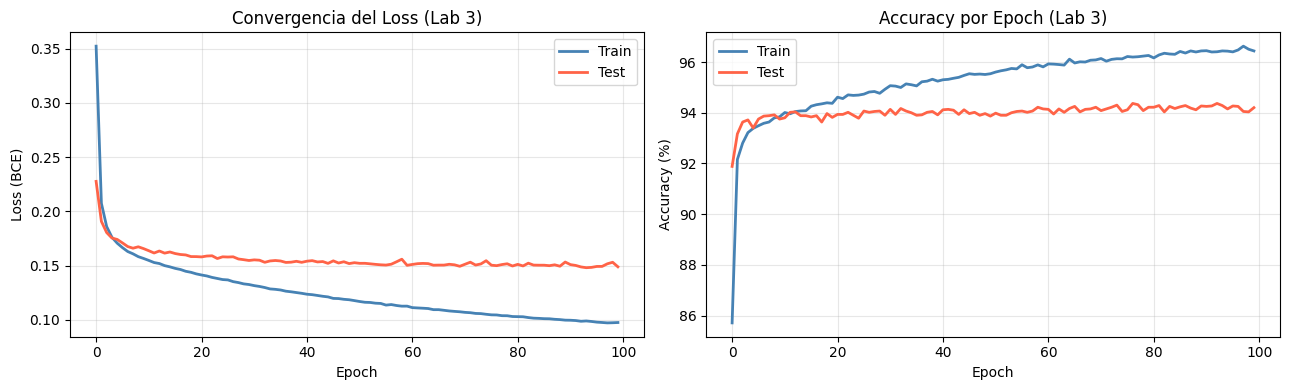

Train Loss final: 0.0975  |  Test Loss final: 0.1488
Train Acc final:  96.44%   |  Test Acc final:  94.20%


In [17]:
# Graficas: Train vs Test — Loss y Accuracy
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses,      color='steelblue', lw=2, label='Train')
axes[0].plot(test_losses_epoch, color='tomato',    lw=2, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Convergencia del Loss (Lab 3)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs,       color='steelblue', lw=2, label='Train')
axes[1].plot(test_accs_epoch,  color='tomato',    lw=2, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por Epoch (Lab 3)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final: {train_losses[-1]:.4f}  |  Test Loss final: {test_losses_epoch[-1]:.4f}')
print(f'Train Acc final:  {train_accs[-1]:.2f}%   |  Test Acc final:  {test_accs_epoch[-1]:.2f}%')


In [18]:
# PASO 8A: Resultados finales en el conjunto de prueba
# (ya calculados epoch a epoca — tomamos el ultimo valor)
print('═══════════════════════════════════════')
print('        EVALUACION EN TEST             ')
print('═══════════════════════════════════════')
print(f'Loss en Test:     {test_losses_epoch[-1]:.4f}')
print(f'Accuracy en Test: {test_accs_epoch[-1]:.2f}%')
print('═══════════════════════════════════════')


═══════════════════════════════════════
        EVALUACION EN TEST             
═══════════════════════════════════════
Loss en Test:     0.1488
Accuracy en Test: 94.20%
═══════════════════════════════════════


# PASO 8: Predicciones individuales — 3 que fallecen y 3 que sobreviven del TEST

In [19]:

idx_fallece   = np.where(y_test_np == 1)[0][:3]
idx_sobrevive = np.where(y_test_np == 0)[0][:3]
indices = np.concatenate([idx_fallece, idx_sobrevive])

print('═══════════════════════════════════════════════════════')
print('           PREDICCION PACIENTES DEL TEST               ')
print('═══════════════════════════════════════════════════════')
print(f"{'Paciente':<12} {'P(Fallece)':<15} {'Prediccion':<12} {'Real':<8} {'Estado'}")
print('-' * 57)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        paciente = X_test[idx].unsqueeze(0)
        prob  = model(paciente).squeeze().item()
        pred  = 1 if prob >= 0.5 else 0
        real  = int(y_test[idx].item())
        estado = '✅ Correcto' if pred == real else '❌ Incorrecto'
        print(f'{i+1:<12} {prob:<15.4f} {pred:<12} {real:<8} {estado}')

print('═══════════════════════════════════════════════════════')


═══════════════════════════════════════════════════════
           PREDICCION PACIENTES DEL TEST               
═══════════════════════════════════════════════════════
Paciente     P(Fallece)      Prediccion   Real     Estado
---------------------------------------------------------
1            1.0000          1            1        ✅ Correcto
2            1.0000          1            1        ✅ Correcto
3            1.0000          1            1        ✅ Correcto
4            0.0036          0            0        ✅ Correcto
5            0.0233          0            0        ✅ Correcto
6            0.1705          0            0        ✅ Correcto
═══════════════════════════════════════════════════════


In [66]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print("✅ Mejor modelo cargado correctamente")


✅ Mejor modelo cargado correctamente


# Laboratorio 4 - Clasificacion Multiclase de Gestos (PyTorch)

**Nombre:** Alcibia Miranda Yulitza

**Grupo:** 2

## Dataset Multimodal: Gestos de Mano (Hand Gestures)
URL: https://drive.google.com/drive/folders/1wuD5wpJbz3yYgZLJAz8WrMMGLrhbIebu?usp=sharing

---

### Descripcion del Dataset
El dataset contiene imagenes en escala de grises de gestos de mano.
Cada imagen se redimensiona a **20x20 pixeles**, generando **400 features** por ejemplo.

**Numero de features (n):** 400  
**Numero de ejemplos (m):** ~7,000  
**Numero de clases (K):** 7

### Clases
- `0` - fist
- `1` - five
- `2` - okay
- `3` - peace
- `4` - rad
- `5` - straight
- `6` - thumbs

### Estrategia del Modelo
Se entrena una **red neuronal multiclase** con PyTorch y `CrossEntropyLoss`.
La prediccion final se obtiene con `argmax` sobre las 7 salidas del modelo.

$$\hat{y} = \arg\max_k f_\theta(x)_k$$

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
from scipy import optimize
import cv2
import os
import glob
from matplotlib import pyplot
%matplotlib inline
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")
print('Librerías importadas correctamente.')

Usando: cpu
Librerías importadas correctamente.


In [37]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado correctamente.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado correctamente.


##PASO 1: Cargar imágenes

In [38]:
clases = ['fist', 'five', 'okay', 'peace', 'rad', 'straight', 'thumbs']
num_labels = len(clases)
input_layer_size = 20 * 20
ruta_base = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/data/'

def cargar_datos(carpeta):

    X_list = []
    y_list = []

    for etiqueta, clase in enumerate(clases):
        ruta = ruta_base + carpeta + '/' + clase + '/*.png'
        imagenes = glob.glob(ruta)

        for imagen_path in imagenes:
            imagen = cv2.imread(imagen_path, cv2.IMREAD_GRAYSCALE)
            imagen = cv2.resize(imagen, (20, 20))   # 20x20
            imagen = imagen.flatten() / 255.0        # normalizar a [0, 1]
            X_list.append(imagen)
            y_list.append(etiqueta)

    return np.array(X_list), np.array(y_list)

X_raw, y_raw = cargar_datos('train')

m_total = y_raw.size
print(f"Total imágenes cargadas: {X_raw.shape[0]}")
print(f"Features por imagen:     {X_raw.shape[1]}  (= 20x20)")
print(f"Clases encontradas:      {np.unique(y_raw)}  ({num_labels} clases)")

Total imágenes cargadas: 6999
Features por imagen:     400  (= 20x20)
Clases encontradas:      [0 1 2 3 4 5 6]  (7 clases)


##PASO 2: Dividir train/test


In [40]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw    # garantiza misma proporción de clases
)

print(f"Entrenamiento: {X.shape[0]} imágenes")
print(f"Prueba:        {X_test.shape[0]} imágenes")

Entrenamiento: 5599 imágenes
Prueba:        1400 imágenes


##PASO 3: Convertir a tensores

In [41]:
# Convertir a tensores
X_tensor      = torch.from_numpy(X).float().to(device)
y_tensor      = torch.from_numpy(y).long().to(device)
X_test_tensor = torch.from_numpy(X_test).float().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

print(f"X train: {X_tensor.shape}")       # → (5600, 400)
print(f"y train: {y_tensor.shape}")       # → (5600,)
print(f"X test:  {X_test_tensor.shape}")  # → (1400, 400)

X train: torch.Size([5599, 400])
y train: torch.Size([5599])
X test:  torch.Size([1400, 400])


##PASO 4: Crear Dataset

In [42]:

class GestosDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


# Crear datasets
train_dataset = GestosDataset(X_tensor, y_tensor)
test_dataset  = GestosDataset(X_test_tensor, y_test_tensor)

print(f"Imágenes entrenamiento: {len(train_dataset)}")
print(f"Imágenes evaluación:    {len(test_dataset)}")


Imágenes entrenamiento: 5599
Imágenes evaluación:    1400


##PASO 5: Crear DataLoader

In [43]:

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Batches entrenamiento: {len(train_loader)}")
print(f"Batches evaluación:    {len(test_loader)}")


Batches entrenamiento: 88
Batches evaluación:    22


##PASO 6: DEFINICION DE LA RED NEURAL SECUENCIAL

In [44]:
D_in  = 400   # features: 20×20 píxeles
H     = 128   # neuronas ocultas
D_out = 7     # una salida por cada gesto

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa 1: 400 → 128
    torch.nn.ReLU(),             # activación
    torch.nn.Linear(H, D_out),  # capa 2: 128 → 7
).to(device)

print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters())}")


Sequential(
  (0): Linear(in_features=400, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=7, bias=True)
)

Parámetros totales: 52231


## PASO 7: Loss y Optimizador


### Loss y Optimizador

`CrossEntropyLoss` es la función de pérdida estándar para clasificación multiclase.
Internamente aplica Softmax sobre las 7 salidas del modelo y calcula la entropía cruzada
contra la clase real. Por eso la última capa del modelo **no** lleva activación Softmax.

`SGD` con `weight_decay=0.001` agrega regularización L2 para penalizar pesos grandes
y reducir el sobreajuste, equivalente al parámetro `lambda_` de laboratorios anteriores.


In [45]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.001
)


##PASO 8: Entrenamiento

### Explicacion del entrenamiento multiclase
El modelo produce 7 puntajes por imagen (uno por gesto).
`CrossEntropyLoss` compara esos puntajes con la clase real y optimiza pesos.
La prediccion final se obtiene con `argmax` (clase de mayor puntaje).

In [46]:
# PASO 9: Entrenamiento
epochs   = 100
log_each = 10
train_losses = []
train_accs   = []
test_losses_epoch = []
test_accs_epoch   = []
best_loss    = float('inf')
PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_gestos.pt'

for e in range(1, epochs + 1):

    # ── Fase entrenamiento ──
    model.train()
    batch_losses = []
    batch_accs   = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_b)
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        y_clase = torch.argmax(y_pred, dim=1)
        batch_accs.append((y_clase == y_b).float().mean().item() * 100)
        loss.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc  = np.mean(batch_accs)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # ── Fase evaluacion en test ──
    model.eval()
    with torch.no_grad():
        t_losses, t_accs = [], []
        for x_b, y_b in test_loader:
            y_pred  = model(x_b)
            t_losses.append(criterion(y_pred, y_b).item())
            y_clase = torch.argmax(y_pred, dim=1)
            t_accs.append((y_clase == y_b).float().mean().item() * 100)
        test_loss_e = np.mean(t_losses)
        test_acc_e  = np.mean(t_accs)
        test_losses_epoch.append(test_loss_e)
        test_accs_epoch.append(test_acc_e)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), PATH)
        print(f'✅ Epoch {e}: guardado (Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%)')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  TrainLoss: {epoch_loss:.4f}  TestLoss: {test_loss_e:.4f}  TestAcc: {test_acc_e:.2f}%')


✅ Epoch 1: guardado (Train Loss: 1.8568 | Train Acc: 32.95%)
✅ Epoch 2: guardado (Train Loss: 1.6704 | Train Acc: 47.10%)
✅ Epoch 3: guardado (Train Loss: 1.5019 | Train Acc: 52.71%)
✅ Epoch 4: guardado (Train Loss: 1.3706 | Train Acc: 55.89%)
✅ Epoch 5: guardado (Train Loss: 1.2626 | Train Acc: 59.25%)
✅ Epoch 6: guardado (Train Loss: 1.1720 | Train Acc: 62.58%)
✅ Epoch 7: guardado (Train Loss: 1.0942 | Train Acc: 64.63%)
✅ Epoch 8: guardado (Train Loss: 1.0186 | Train Acc: 68.37%)
✅ Epoch 9: guardado (Train Loss: 0.9516 | Train Acc: 71.39%)
✅ Epoch 10: guardado (Train Loss: 0.8907 | Train Acc: 74.39%)
Epoch 10/100  TrainLoss: 0.8907  TestLoss: 0.8465  TestAcc: 76.31%
✅ Epoch 11: guardado (Train Loss: 0.8345 | Train Acc: 76.79%)
✅ Epoch 12: guardado (Train Loss: 0.7832 | Train Acc: 78.58%)
✅ Epoch 13: guardado (Train Loss: 0.7381 | Train Acc: 80.07%)
✅ Epoch 14: guardado (Train Loss: 0.6972 | Train Acc: 81.15%)
✅ Epoch 15: guardado (Train Loss: 0.6589 | Train Acc: 82.66%)
✅ Epoch 16: 

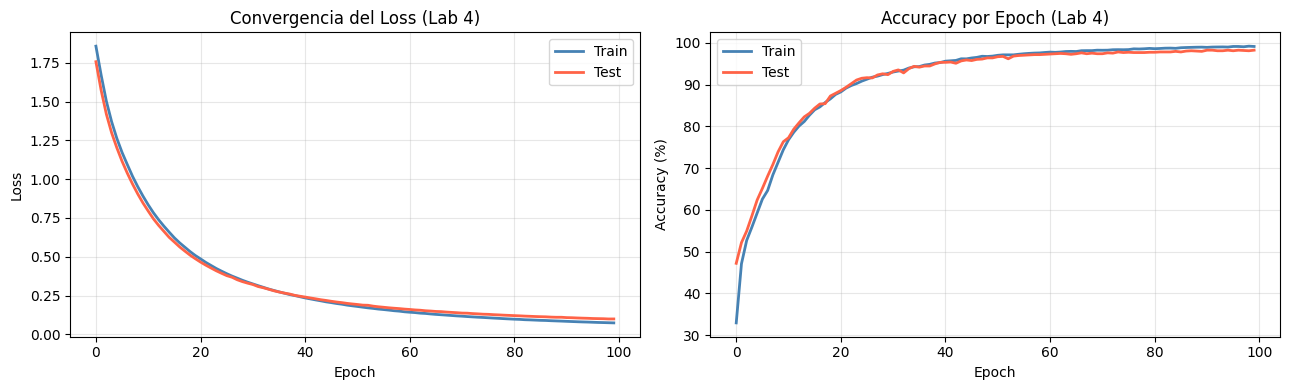

Train Loss final: 0.0743  |  Test Loss final: 0.0997
Train Acc final:  99.11%   |  Test Acc final:  98.22%


In [47]:
# Graficas: Train vs Test — Loss y Accuracy
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses,      color='steelblue', lw=2, label='Train')
axes[0].plot(test_losses_epoch, color='tomato',    lw=2, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Convergencia del Loss (Lab 4)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs,       color='steelblue', lw=2, label='Train')
axes[1].plot(test_accs_epoch,  color='tomato',    lw=2, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por Epoch (Lab 4)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final: {train_losses[-1]:.4f}  |  Test Loss final: {test_losses_epoch[-1]:.4f}')
print(f'Train Acc final:  {train_accs[-1]:.2f}%   |  Test Acc final:  {test_accs_epoch[-1]:.2f}%')


##PASO 9: Evaluar y Predecir

In [48]:

print('═══════════════════════════════════════')
print('        EVALUACION EN TEST             ')
print('═══════════════════════════════════════')
print(f'Loss en Test:     {test_losses_epoch[-1]:.4f}')
print(f'Accuracy en Test: {test_accs_epoch[-1]:.2f}%')
print('═══════════════════════════════════════')


═══════════════════════════════════════
        EVALUACION EN TEST             
═══════════════════════════════════════
Loss en Test:     0.0997
Accuracy en Test: 98.22%
═══════════════════════════════════════


In [49]:
# PASO 9A: Predecir imágenes del test

# Agarrar 7 imágenes, una de cada clase
indices = []
for clase in range(7):
    idx = np.where(y_test == clase)[0][0]
    indices.append(idx)

print("═══════════════════════════════════════════════════════")
print("           PREDICCIÓN DE GESTOS NUEVOS                ")
print("═══════════════════════════════════════════════════════")
print(f"{'Imagen':<10} {'Predicción':<15} {'Real':<15} {'Estado'}")
print("-" * 55)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):

        # Agarrar imagen
        imagen = X_test_tensor[idx].unsqueeze(0)   # (1, 400)

        # Predecir
        y_pred  = model(imagen)
        pred    = torch.argmax(y_pred, dim=1).item()
        real    = y_test[idx]
        estado  = "✅ Correcto" if pred == real else "❌ Incorrecto"

        print(f"{i+1:<10} {clases[pred]:<15} {clases[real]:<15} {estado}")

print("═══════════════════════════════════════════════════════")

═══════════════════════════════════════════════════════
           PREDICCIÓN DE GESTOS NUEVOS                
═══════════════════════════════════════════════════════
Imagen     Predicción      Real            Estado
-------------------------------------------------------
1          fist            fist            ✅ Correcto
2          five            five            ✅ Correcto
3          okay            okay            ✅ Correcto
4          peace           peace           ✅ Correcto
5          rad             rad             ✅ Correcto
6          straight        straight        ✅ Correcto
7          thumbs          thumbs          ✅ Correcto
═══════════════════════════════════════════════════════


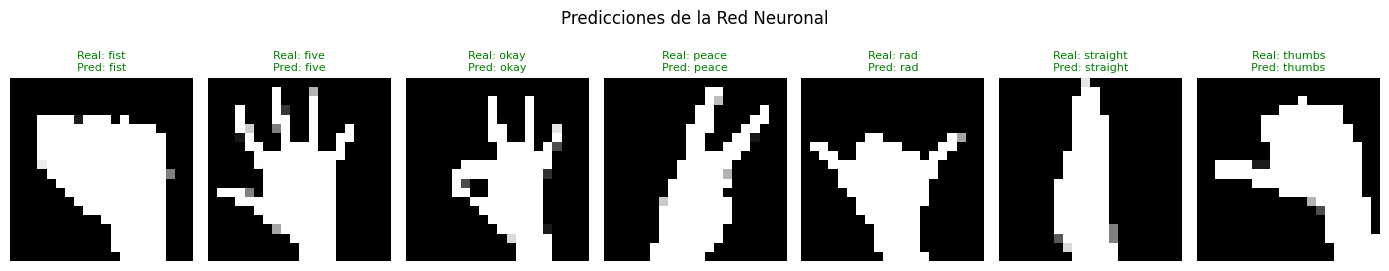

In [50]:
# PASO 9B: Mostrar imágenes con predicciones

fig, axes = pyplot.subplots(1, 7, figsize=(14, 3))

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):

        imagen        = X_test_tensor[idx].unsqueeze(0)
        y_pred        = model(imagen)
        pred          = torch.argmax(y_pred, dim=1).item()
        real          = y_test[idx]

        # Mostrar imagen
        axes[i].imshow(
            X_test[idx].reshape(20, 20),
            cmap='gray'
        )
        color = 'green' if pred == real else 'red'
        axes[i].set_title(
            f"Real: {clases[real]}\nPred: {clases[pred]}",
            color=color,
            fontsize=8
        )
        axes[i].axis('off')

pyplot.suptitle('Predicciones de la Red Neuronal', fontsize=12)
pyplot.tight_layout()
pyplot.show()

In [51]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print("✅ Mejor modelo cargado correctamente")


✅ Mejor modelo cargado correctamente
